# Sequence Windows for Quantum Forecasting

Use `make_sequence_windows` to convert a time series into supervised examples, then fit the dataset-agnostic `QuantumRegressor` as a one-step-ahead forecaster.

## Tutorial Goals

This tutorial combines preprocessing and estimation for a short forecasting task. You will:

- use `make_sequence_windows` to convert a signal into supervised samples
- fit `QuantumRegressor` as a one-step forecaster
- compare forecasts against a ridge baseline
- validate the generated window shapes and prediction metrics

The pattern generalizes to other short-window time-series problems.

## Problem, Variables, and Quantum Advantage Context

**Forecasting problem.** A smooth oscillatory signal is observed at regular times. The task is to forecast the next scalar value from the previous three values.

**Explicit variables.** `signal` is the raw time series. `window_size` controls how many past values form each feature vector. `x_windows` and `y_windows` are the supervised arrays returned by `make_sequence_windows`. `q_forecast` and `ridge_forecast` are held-out one-step-ahead predictions.

**Quantum advantage context.** Quantum regressors can encode nonlinear functions of short temporal windows through circuit feature maps. This notebook does **not** establish quantum advantage; it validates the preprocessing helper and estimator together on a small reproducible forecasting task.

In [1]:
from pathlib import Path
import sys
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/mplconfig")

repo_root = Path.cwd().resolve()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
elif not (repo_root / "src" / "qml").exists():
    repo_root = next((parent for parent in repo_root.parents if (parent / "src" / "qml").exists()), repo_root)

package_root = repo_root / "src"
if str(package_root) not in sys.path:
    sys.path.insert(0, str(package_root))

import numpy as np
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

from qml import QuantumRegressor, make_sequence_windows
from qml.metrics import mean_absolute_error, mean_squared_error
from qml.reporting import print_section


## Domain simulator

The signal combines a dominant sinusoid with a smaller third harmonic. `make_sequence_windows` turns the sequence into flattened windows and next-step targets.

In [2]:
time = np.linspace(0.0, 8.0 * np.pi, 44)
signal = np.sin(time) + 0.15 * np.sin(3.0 * time)

window_size = 3
horizon = 1
x_windows, y_windows = make_sequence_windows(
    signal, window_size=window_size, horizon=horizon, stride=1
)

x_train, x_test, y_train, y_test = train_test_split(
    x_windows, y_windows, test_size=0.25, random_state=51, shuffle=False
)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

print_section(
    "Dataset",
    [
        ("Raw signal steps", int(len(signal))),
        ("Window size", int(window_size)),
        ("Horizon", int(horizon)),
        ("Windowed feature_shape", list(x_windows.shape)),
        ("Target shape", list(y_windows.shape)),
        ("Train windows", int(len(y_train))),
        ("Test windows", int(len(y_test))),
    ],
)

Dataset
+------------------------+---------+
| Metric                 | Value   |
+------------------------+---------+
| Raw signal steps       | 44      |
| Window size            | 3       |
| Horizon                | 1       |
| Windowed feature_shape | [41, 3] |
| Target shape           | [41]    |
| Train windows          | 30      |
| Test windows           | 11      |
+------------------------+---------+



## Package-client quantum forecaster

In [3]:
q_forecaster = QuantumRegressor(n_layers=1, steps=20, step_size=0.06, seed=51)
q_forecaster.fit(x_train, y_train)
q_forecast = q_forecaster.predict(x_test)

ridge_forecaster = Ridge(alpha=1e-3)
ridge_forecaster.fit(x_train, y_train)
ridge_forecast = ridge_forecaster.predict(x_test)

loss_history = q_forecaster.loss_history_[0]
results = {
    "quantum_forecast_mae": mean_absolute_error(y_test, q_forecast),
    "quantum_forecast_mse": mean_squared_error(y_test, q_forecast),
    "ridge_forecast_mae": mean_absolute_error(y_test, ridge_forecast),
    "initial_loss": float(loss_history[0]),
    "final_loss": float(loss_history[-1]),
    "loss_steps": len(loss_history),
}

print_section(
    "Results",
    [
        ("Quantum forecast MAE", results["quantum_forecast_mae"]),
        ("Quantum forecast MSE", results["quantum_forecast_mse"]),
        ("Ridge forecast MAE", results["ridge_forecast_mae"]),
        ("Initial loss", results["initial_loss"]),
        ("Final loss", results["final_loss"]),
        ("Loss steps", results["loss_steps"]),
    ],
)

Results
+----------------------+----------+
| Metric               | Value    |
+----------------------+----------+
| Quantum forecast MAE | 0.406761 |
| Quantum forecast MSE | 0.207272 |
| Ridge forecast MAE   | 0.182912 |
| Initial loss         | 0.715744 |
| Final loss           | 0.222213 |
| Loss steps           | 20       |
+----------------------+----------+



## Plots

The plots show the original signal, training loss, and held-out one-step forecasts.

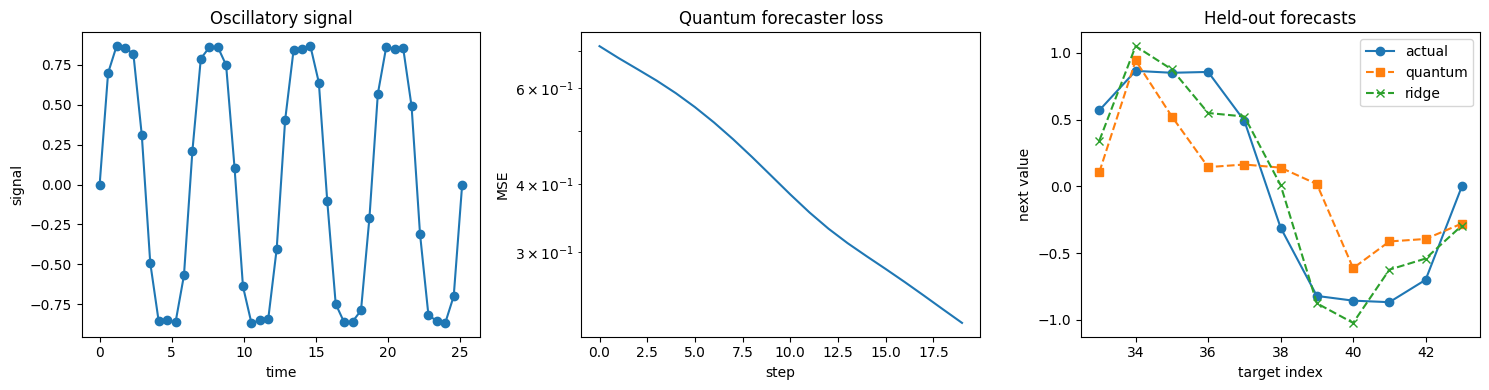

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

target_indices = np.arange(window_size + horizon - 1, len(signal))
test_indices = target_indices[-len(y_test):]

axes[0].plot(time, signal, marker="o", linewidth=1.5)
axes[0].set_title("Oscillatory signal")
axes[0].set_xlabel("time")
axes[0].set_ylabel("signal")

axes[1].plot(loss_history, color="tab:blue")
axes[1].set_title("Quantum forecaster loss")
axes[1].set_xlabel("step")
axes[1].set_ylabel("MSE")
axes[1].set_yscale("log")

axes[2].plot(test_indices, y_test, "o-", label="actual")
axes[2].plot(test_indices, q_forecast, "s--", label="quantum")
axes[2].plot(test_indices, ridge_forecast, "x--", label="ridge")
axes[2].set_title("Held-out forecasts")
axes[2].set_xlabel("target index")
axes[2].set_ylabel("next value")
axes[2].legend()

fig.tight_layout()
plt.show()

## Validation block

This final cell checks the window shapes, finite forecasts, and quantum training-loss reduction.

In [5]:
validation = {
    "dataset": {
        "problem": "sequence_window_quantum_forecasting",
        "features": [f"signal_t_minus_{offset}" for offset in range(window_size - 1, -1, -1)],
        "target": "next_signal_value",
        "raw_signal_steps": int(len(signal)),
        "n_train": int(len(y_train)),
        "n_test": int(len(y_test)),
    },
    "results": results,
    "sample_forecasts": [
        {"actual": float(a), "quantum": float(q), "ridge": float(r)}
        for a, q, r in zip(y_test[:6], q_forecast[:6], ridge_forecast[:6])
    ],
    "passed": bool(
        x_windows.shape[1] == window_size
        and y_windows.ndim == 1
        and np.isfinite(q_forecast).all()
        and results["final_loss"] < results["initial_loss"]
        and results["quantum_forecast_mae"] < 0.55
    ),
}

print("Validation")
print_section(
    "Dataset",
    [
        ("Problem", validation["dataset"]["problem"]),
        ("Features", validation["dataset"]["features"]),
        ("Target", validation["dataset"]["target"]),
        ("Raw signal steps", validation["dataset"]["raw_signal_steps"]),
        ("Train windows", validation["dataset"]["n_train"]),
        ("Test windows", validation["dataset"]["n_test"]),
    ],
)
print_section(
    "Results",
    [
        ("Quantum forecast MAE", validation["results"]["quantum_forecast_mae"]),
        ("Quantum forecast MSE", validation["results"]["quantum_forecast_mse"]),
        ("Ridge forecast MAE", validation["results"]["ridge_forecast_mae"]),
        ("Initial loss", validation["results"]["initial_loss"]),
        ("Final loss", validation["results"]["final_loss"]),
        ("Loss steps", validation["results"]["loss_steps"]),
    ],
)
print("Sample forecasts")
for index, row in enumerate(validation["sample_forecasts"], start=1):
    print(
        f"{index}. Actual: {row['actual']:.6f}, "
        f"Quantum: {row['quantum']:.6f}, "
        f"Ridge: {row['ridge']:.6f}"
    )
print()
print("Interpretation")
print("The preprocessing helper created valid supervised windows and the quantum regressor reduced training loss.")
print("The ridge baseline is included as a sanity check; no quantum advantage is claimed.")
print()
print(f"Passed: {validation['passed']}")
assert validation["passed"]

Validation
Dataset
+------------------+--------------------------------------------------------+
| Metric           | Value                                                  |
+------------------+--------------------------------------------------------+
| Problem          | sequence_window_quantum_forecasting                    |
| Features         | [signal_t_minus_2, signal_t_minus_1, signal_t_minus_0] |
| Target           | next_signal_value                                      |
| Raw signal steps | 44                                                     |
| Train windows    | 30                                                     |
| Test windows     | 11                                                     |
+------------------+--------------------------------------------------------+

Results
+----------------------+----------+
| Metric               | Value    |
+----------------------+----------+
| Quantum forecast MAE | 0.406761 |
| Quantum forecast MSE | 0.207272 |
| Ridge fore